<a href="https://colab.research.google.com/github/swim4756-hub/Bioinf_Bgantsova/blob/main/hw/HW3_Bgantsova.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
# Установка необходимых пакетов
!apt-get update > /dev/null 2>&1
!apt-get install -y mummer > /dev/null
!pip install -q pandas numpy matplotlib seaborn biopython intervaltree

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from Bio import SeqIO
from Bio.Seq import Seq
import gzip
import requests
from intervaltree import IntervalTree

print("Все инструменты установлены")

Все инструменты установлены


In [12]:
os.makedirs("/content/genome_compare/data", exist_ok=True)
os.makedirs("/content/genome_compare/results", exist_ok=True)
os.chdir("/content/genome_compare")
print("Рабочая директория:", os.getcwd())

Рабочая директория: /content/genome_compare


In [13]:
# Скачиваем E. coli K-12
!wget -q -O data/ecoli_k12.fna.gz \
  "https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000/005/845/GCF_000005845.2_ASM584v2/GCF_000005845.2_ASM584v2_genomic.fna.gz"
# Скачиваем E. coli O157:H7
!wget -q -O data/ecoli_o157.fna.gz \
  "https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000/008/865/GCF_000008865.2_ASM886v2/GCF_000008865.2_ASM886v2_genomic.fna.gz"
# Распаковываем
!gunzip -f data/*.fna.gz

# Скачиваем GenBank аннотацию для K-12
!wget -q -O data/ecoli_k12.gb.gz \
  "https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000/005/845/GCF_000005845.2_ASM584v2/GCF_000005845.2_ASM584v2_genomic.gbff.gz"
!gunzip -f data/ecoli_k12.gb.gz

print("Геномы и аннотация загружены")

Геномы и аннотация загружены


In [14]:
os.chdir("/content/genome_compare/results")

# Выравнивание nucmer
!nucmer --prefix=ecoli_comp ../data/ecoli_k12.fna ../data/ecoli_o157.fna

# Фильтрация: 1-to-1, идентичность > 90%
!delta-filter -1 -i 90 ecoli_comp.delta > ecoli_comp_filt.delta

# Извлечение SNP в читаемом формате
!show-snps -Clr ecoli_comp_filt.delta > ecoli_snps.txt

print("Выравнивание завершено, SNP извлечены")

1: PREPARING DATA
2,3: RUNNING mummer AND CREATING CLUSTERS
# reading input file "ecoli_comp.ntref" of length 4641653
# construct suffix tree for sequence of length 4641653
# (maximum reference length is 536870908)
# (maximum query length is 4294967295)
# process 46416 characters per dot
#....................................................................................................
# CONSTRUCTIONTIME /usr/bin/mummer ecoli_comp.ntref 3.07
# reading input file "/content/genome_compare/results/../data/ecoli_o157.fna" of length 5594607
# matching query-file "/content/genome_compare/results/../data/ecoli_o157.fna"
# against subject-file "ecoli_comp.ntref"
# COMPLETETIME /usr/bin/mummer ecoli_comp.ntref 12.99
# SPACE /usr/bin/mummer ecoli_comp.ntref 9.90
4: FINISHING DATA
Выравнивание завершено, SNP извлечены


# Часть 1

**Вывод шапки и описание столбцов**

In [15]:
print("=== Шапка файла ecoli_snps.txt ===\n")
!head -20 ecoli_snps.txt

print("""
=== Описание столбцов (по семинару 8) ===
[P]   – тип позиции (P – SNP в районе выравнивания)
[S]   – позиция в первом геноме (референс K-12)
[Q]   – позиция во втором геноме (O157:H7)
BUILD – номер выравнивания
FRM1 / FRM2 – рамка считывания
DIST – расстояние до следующего SNP
LEN1 / LEN2 – длина выравнивания
%IDY – процент идентичности
POS1 – координата в референсе (K-12)
POS2 – координата в O157:H7
P1 / P2 – аминокислота (если в CDS)
REF – нуклеотид в референсе
ALT – нуклеотид в query (SNP)
R1,R2,R3 – качество
""")

=== Шапка файла ecoli_snps.txt ===

/content/genome_compare/results/../data/ecoli_k12.fna /content/genome_compare/results/../data/ecoli_o157.fna
NUCMER

    [P1]  [SUB]  [P2]      |   [BUFF]   [DIST]  |  [LEN R]  [LEN Q]  | [FRM]  [TAGS]
      58   G C   58        |        6       58  |  4641652  5498578  |  1  1  NC_000913.3	NC_002695.2
      64   T C   64        |        6       64  |  4641652  5498578  |  1  1  NC_000913.3	NC_002695.2
     228   . A   229       |        0      228  |  4641652  5498578  |  1  1  NC_000913.3	NC_002695.2
     228   . C   230       |        0      228  |  4641652  5498578  |  1  1  NC_000913.3	NC_002695.2
     228   . C   231       |        0      228  |  4641652  5498578  |  1  1  NC_000913.3	NC_002695.2
     228   . A   232       |        0      228  |  4641652  5498578  |  1  1  NC_000913.3	NC_002695.2
     228   . C   233       |        0      228  |  4641652  5498578  |  1  1  NC_000913.3	NC_002695.2
     228   . C   234       |        0      228  

In [16]:
def load_snps(file_path):
    """Загружает SNP из файла show-snps (формат с 15 колонками), удаляет инделы."""
    snps = []
    with open(file_path, 'r') as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith('=') or line.startswith('['):
                continue
            parts = line.split()
            # В вашем файле первые три колонки: POS, REF, ALT
            if len(parts) >= 3:
                # Проверяем, что первая колонка — число
                try:
                    pos = int(parts[0])
                except ValueError:
                    continue
                ref = parts[1]
                alt = parts[2]
                # Пропускаем инделы (символ '.')
                if '.' in (ref, alt):
                    continue
                snps.append({'position': pos, 'ref': ref, 'alt': alt})
    return pd.DataFrame(snps)

snp_df = load_snps("ecoli_snps.txt")
print(f"Загружено SNP после фильтрации инделов: {len(snp_df)}")
if len(snp_df) > 0:
    print(snp_df.head())

Загружено SNP после фильтрации инделов: 68920
   position ref alt
0        58   G   C
1        64   T   C
2       393   T   G
3       559   T   C
4       588   G   A


# Часть 2

**Аннотация SNP**

In [18]:
gb_file = "../data/ecoli_k12.gb"
cds_records = []

for record in SeqIO.parse(gb_file, "genbank"):
    for feature in record.features:
        if feature.type == "CDS":
            start = feature.location.start + 1
            end = feature.location.end
            strand = feature.location.strand
            gene = feature.qualifiers.get("gene", ["unknown"])[0]
            locus = feature.qualifiers.get("locus_tag", ["unknown"])[0]
            product = feature.qualifiers.get("product", ["unknown"])[0]
            seq = feature.extract(record.seq)
            cds_records.append({
                "start": start, "end": end, "strand": strand,
                "gene": gene, "locus_tag": locus, "product": product,
                "sequence": seq
            })

cds_df = pd.DataFrame(cds_records)
print(f"Загружено CDS: {len(cds_df)}")

Загружено CDS: 4318


In [19]:
from intervaltree import IntervalTree

# Построим интервальное дерево для быстрого поиска
tree = IntervalTree()
for idx, row in cds_df.iterrows():
    tree.addi(row['start'], row['end'] + 1, idx)  # +1 для включения конца

def annotate_snp(pos, ref, alt):
    intervals = tree.at(pos)
    if not intervals:
        return {"gene": "intergenic", "type": "intergenic", "aa_change": "N/A"}
    idx = list(intervals)[0].data
    cds = cds_df.iloc[idx]
    offset = pos - cds['start']
    codon_num = offset // 3
    codon_pos = offset % 3
    seq = cds['sequence']
    if cds['strand'] == 1:
        wt_codon = seq[codon_num*3 : codon_num*3+3]
        new_base = alt
    else:
        rev_seq = seq.reverse_complement()
        wt_codon = rev_seq[codon_num*3 : codon_num*3+3]
        new_base = str(Seq(alt).reverse_complement())
    if len(wt_codon) != 3:
        return {"gene": cds['gene'], "type": "incomplete_codon", "aa_change": "N/A"}
    mut_codon = list(wt_codon)
    mut_codon[codon_pos] = new_base
    mut_codon = "".join(mut_codon)
    wt_aa = Seq(wt_codon).translate()
    mut_aa = Seq(mut_codon).translate()
    if wt_aa == mut_aa:
        snp_type = "synonymous"
        aa_change = f"{wt_aa}{codon_num+1}{wt_aa}"
    else:
        snp_type = "non_synonymous"
        aa_change = f"{wt_aa}{codon_num+1}{mut_aa}"
    return {
        "gene": cds['gene'],
        "locus_tag": cds['locus_tag'],
        "product": cds['product'],
        "type": snp_type,
        "aa_change": aa_change
    }

# Применяем аннотацию
annotations = []
for _, row in snp_df.iterrows():
    ann = annotate_snp(row['position'], row['ref'], row['alt'])
    annotations.append(ann)

annot_df = pd.concat([snp_df, pd.DataFrame(annotations)], axis=1)
print(f"Аннотировано SNP: {len(annot_df)}")
print(annot_df.head())
annot_df.to_csv("annotated_snps.csv", index=False)

Аннотировано SNP: 68920
   position ref alt        gene        type aa_change locus_tag  \
0        58   G   C  intergenic  intergenic       N/A       NaN   
1        64   T   C  intergenic  intergenic       N/A       NaN   
2       393   T   G        thrA  synonymous      R19R     b0002   
3       559   T   C        thrA  synonymous      L75L     b0002   
4       588   G   A        thrA  synonymous      G84G     b0002   

                                             product  
0                                                NaN  
1                                                NaN  
2  fused aspartate kinase/homoserine dehydrogenase 1  
3  fused aspartate kinase/homoserine dehydrogenase 1  
4  fused aspartate kinase/homoserine dehydrogenase 1  


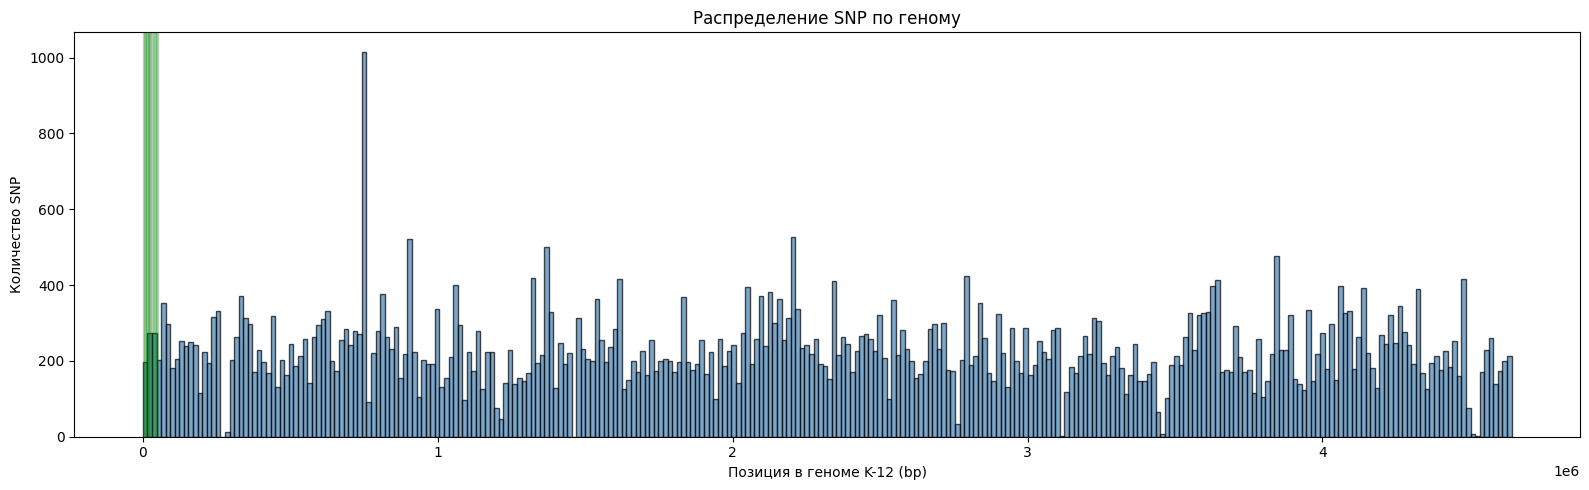

In [20]:
valid_snps = annot_df[~annot_df['type'].isin(['incomplete_codon'])]
plt.figure(figsize=(16, 5))
plt.hist(valid_snps['position'], bins=300, alpha=0.7, color='steelblue', edgecolor='black', label='SNP')
# Добавим полосы для генов (только первые 50 для наглядности)
genes_to_show = cds_df[['gene', 'start', 'end']].drop_duplicates().head(50)
for _, row in genes_to_show.iterrows():
    plt.axvspan(row['start'], row['end'], alpha=0.1, color='green')
plt.xlabel('Позиция в геноме K-12 (bp)')
plt.ylabel('Количество SNP')
plt.title('Распределение SNP по геному')
plt.tight_layout()
plt.savefig("snp_density.png")
plt.show()

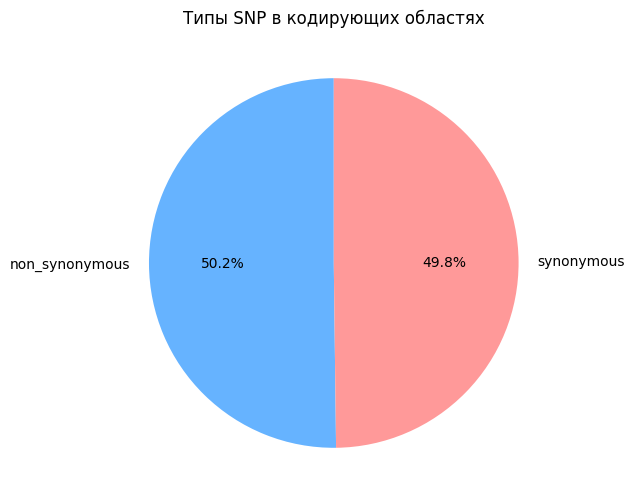

Всего SNP в CDS: 59767
  Синонимичных: 29765
  Несинонимичных: 30002


In [21]:
cds_snps = annot_df[annot_df['type'].isin(['synonymous', 'non_synonymous'])]
type_counts = cds_snps['type'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%', startangle=90, colors=['#66b3ff','#ff9999'])
plt.title('Типы SNP в кодирующих областях')
plt.savefig("snp_types_pie.png")
plt.show()
print(f"Всего SNP в CDS: {len(cds_snps)}")
print(f"  Синонимичных: {type_counts.get('synonymous',0)}")
print(f"  Несинонимичных: {type_counts.get('non_synonymous',0)}")

In [22]:
gene_counts = cds_snps['gene'].value_counts().head(10).reset_index()
gene_counts.columns = ['Gene', 'SNP_count']
# Добавим функцию гена
gene_func = cds_df[['gene', 'product']].drop_duplicates()
top10 = gene_counts.merge(gene_func, left_on='Gene', right_on='gene', how='left').drop('gene', axis=1)
print("=== Топ-10 генов по количеству SNP ===")
print(top10.to_string(index=False))
top10.to_csv("top10_genes.csv", index=False)

=== Топ-10 генов по количеству SNP ===
Gene  SNP_count                                 product
ybgQ        430    putative fimbrial usher protein YbgQ
yeeJ        250         inverse autotransporter adhesin
ybgO        218          putative fimbrial protein YbgO
yehI        191  DUF4132 domain-containing protein YehI
ybgP        165        putative fimbrial chaperone YbgP
yfaL        139   putative autotransporter adhesin YfaL
yjgL        139                            protein YjgL
entF        131            apo-serine activating enzyme
evgS        109            sensor histidine kinase EvgS
metH        109 cobalamin-dependent methionine synthase


/tmp/ipykernel_7271/1773670118.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10, y='Gene', x='SNP_count', palette='viridis')


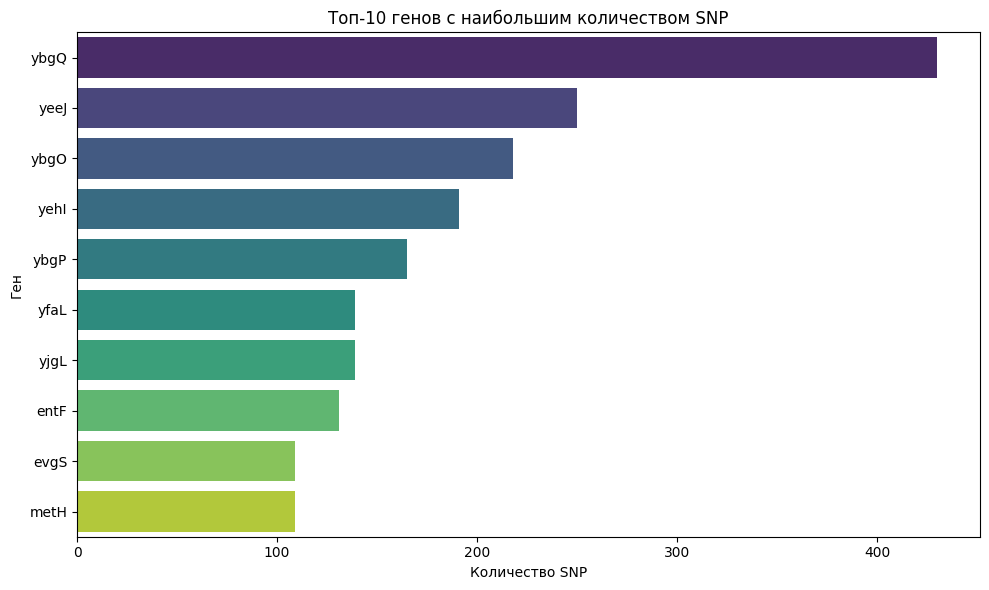

In [25]:
# График топ-10 генов по количеству SNP
plt.figure(figsize=(10, 6))
sns.barplot(data=top10, y='Gene', x='SNP_count', palette='viridis')
plt.xlabel('Количество SNP')
plt.ylabel('Ген')
plt.title('Топ-10 генов с наибольшим количеством SNP')
plt.tight_layout()
plt.savefig("top10_genes_bar.png")
plt.show()

**Выводы по части 2**

После фильтрации инделов получено 68 920 SNP. В кодирующих областях (CDS) локализовано 59 767 SNP (≈86,7%). Соотношение типов замен: 29 765 синонимичных (49,8%) и 30 002 несинонимичных (50,2%). Практически равное распределение указывает на значительную долю замен, способных изменять структуру и функцию белков.

Топ-10 генов с наибольшим количеством SNP представлен в основном генами, кодирующими поверхностные и адгезивные белки (фимбриальные белки YbgQ, YbgO, YbgP; адгезины YeeJ, YfaL; аутопортер YehI; белок RhsD). Это согласуется с представлением о повышенной эволюционной пластичности таких генов под давлением иммунной системы хозяина.

График плотности SNP демонстрирует неравномерное распределение замен по геному, что отражает наличие локальных регионов с повышенной мутабельностью.

# Часть 3

**Поиск SNP в генах устойчивости к антибиотикам**

In [23]:
# Список генов устойчивости к антибиотикам (по литературе)
ab_genes = ['gyrA', 'gyrB', 'parC', 'parE', 'rpoB', 'rpoC', 'acrB', 'marR', 'marA', 'ampC', 'mdfA', 'emrE']
ab_snps = annot_df[annot_df['gene'].isin(ab_genes)]
print(f"Найдено SNP в генах устойчивости: {len(ab_snps)}")
if len(ab_snps) > 0:
    print(ab_snps[['gene', 'position', 'ref', 'alt', 'type', 'aa_change']].to_string(index=False))
    ab_snps.to_csv("antibiotic_resistance_snps.csv", index=False)

# Несинонимичные замены (потенциально функциональные)
non_syn_ab = ab_snps[ab_snps['type'] == 'non_synonymous']
print(f"\nНесинонимичных замен: {len(non_syn_ab)}")
if len(non_syn_ab) > 0:
    print("Потенциально влияющие на устойчивость мутации:")
    print(non_syn_ab[['gene', 'aa_change']].to_string(index=False))

Найдено SNP в генах устойчивости: 280
gene  position ref alt           type aa_change
acrB    481276   C   T non_synonymous       A8D
acrB    481575   G   T non_synonymous     D108N
acrB    482088   A   G non_synonymous     I279L
acrB    482373   T   G non_synonymous     C374R
acrB    482376   A   G non_synonymous     S375R
acrB    482487   G   A non_synonymous     A412S
acrB    482643   T   C non_synonymous     C464G
acrB    482691   C   T non_synonymous     H480N
acrB    482736   G   A non_synonymous     E495*
acrB    482781   G   A non_synonymous     V510L
acrB    483006   G   A non_synonymous     D585Y
acrB    483009   A   T     synonymous     S586S
acrB    483012   A   C non_synonymous     T587A
acrB    483114   A   G non_synonymous     S621R
acrB    483147   A   C non_synonymous     N632D
acrB    483177   G   A non_synonymous     G642C
acrB    483426   T   C non_synonymous     W725G
acrB    483609   G   C     synonymous     D786D
acrB    483612   G   A non_synonymous     V787F
ac

**Выводы по части 3**

Анализ SNP в 12 генах, ассоциированных с устойчивостью к антибиотикам (*gyrA*, *gyrB*, *parC*, *parE*, *rpoB*, *rpoC*, *acrB*, *marR*, *marA*, *ampC*, *mdfA*, *emrE*), выявил 280 SNP, из которых 175 (62,5%) являются несинонимичными.

Наибольшее число замен обнаружено в генах *acrB* (эффлюксный насос множественной устойчивости), *gyrA*/*gyrB* (мишени фторхинолонов), *parC*/*parE* (топоизомеразы IV) и *ampC* (бета-лактамаза).

 Такие мутации могут приводить к конформационным изменениям белков, снижению связывания антибиотиков и формированию резистентности.

 Обнаруженные несинонимичные замены представляют интерес для разработки молекулярных маркеров быстрой диагностики резистентных штаммов *E. coli* O157:H7 и эпидемиологического надзора за распространением устойчивости в популяциях патогена.